In [2]:
# ============================================
# Citi Bike December 2023 preprocessing
# Output columns:
#   id                  -> 0, 1, 2, ...
#   longitude           -> start_lng
#   latitude            -> start_lat
#   trip_duration_minutes -> trip duration in minutes as float
#
# Notes:
# - Dataset: Citi Bike, December 2023
# - trip_duration_minutes is stored as a float
# - seconds are still accounted for, because:
#       trip_duration_minutes = total_seconds / 60.0
# ============================================

import pandas as pd
import numpy as np


# -------------------------------------------------------------------
# 1. Set input/output paths
#    Change these paths to your actual file names
# -------------------------------------------------------------------
input_path = "202312-citibike-tripdata_1.csv"      # or .xlsx
output_path = "boris_citibike_duration.csv"


# -------------------------------------------------------------------
# 2. Read file
#    Supports both CSV and Excel
# -------------------------------------------------------------------
if input_path.lower().endswith(".csv"):
    df = pd.read_csv(input_path)
elif input_path.lower().endswith(".xlsx"):
    df = pd.read_excel(input_path)
else:
    raise ValueError("Unsupported file type. Use .csv or .xlsx")


# -------------------------------------------------------------------
# 3. Check required columns
# -------------------------------------------------------------------
required_cols = ["started_at", "ended_at", "start_lat", "start_lng"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")


# -------------------------------------------------------------------
# 4. Parse datetime columns
#    This is the normal case for Citi Bike raw data
# -------------------------------------------------------------------
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"]   = pd.to_datetime(df["ended_at"], errors="coerce")


# -------------------------------------------------------------------
# 5. Compute trip duration in minutes
#    Stored as float, so seconds are preserved
#    Example: 8 min 30 sec -> 8.5
# -------------------------------------------------------------------
df["trip_duration_minutes"] = (
    (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60.0
)


# -------------------------------------------------------------------
# 6. Keep only valid rows
#    Remove missing values and impossible durations
# -------------------------------------------------------------------
clean_df = df[["start_lng", "start_lat", "trip_duration_minutes"]].copy()

clean_df = clean_df.dropna()

# Keep only positive durations
clean_df = clean_df[clean_df["trip_duration_minutes"] > 0]

# Optional: remove extreme outliers
# Uncomment this if you want to cap to 3 hours, for example
# clean_df = clean_df[clean_df["trip_duration_minutes"] <= 180]


# -------------------------------------------------------------------
# 7. Rename columns for final output
# -------------------------------------------------------------------
clean_df = clean_df.rename(columns={
    "start_lng": "longitude",
    "start_lat": "latitude"
})


# -------------------------------------------------------------------
# 8. Add id from 0 to n-1
# -------------------------------------------------------------------
clean_df = clean_df.reset_index(drop=True)
clean_df.insert(0, "id", np.arange(len(clean_df), dtype=int))


# -------------------------------------------------------------------
# 9. Save to CSV
# -------------------------------------------------------------------
clean_df.to_csv(output_path, index=False)


# -------------------------------------------------------------------
# 10. Preview
# -------------------------------------------------------------------
print("Saved file:", output_path)
print("Number of rows:", len(clean_df))
display(clean_df.head())

Saved file: boris_citibike_duration.csv
Number of rows: 999316


,id,longitude,latitude,trip_duration_minutes
0,0,-74.009660,40.724055,11.950117
1,1,-73.967146,40.674012,22.369433
2,2,-74.001659,40.724947,32.892667
3,3,-73.981759,40.728547,1.546100
4,4,-73.981759,40.728547,6.236550


----- SANITY CHECKS -----
Number of rows: 999316

Missing values per column:
id                       0
longitude                0
latitude                 0
trip_duration_minutes    0
dtype: int64

Duplicate id count: 0

Trip duration summary (minutes):
count    999316.000000
mean         12.665258
std          40.969222
min           1.000550
25%           4.980046
50%           8.345633
75%          14.074504
max        1500.516217
Name: trip_duration_minutes, dtype: float64

Trips with non-positive duration: 0

Longitude summary:
count    999316.000000
mean        -73.972774
std           0.028024
min         -74.071262
25%         -73.992085
50%         -73.980472
75%         -73.956981
max         -73.849780
Name: longitude, dtype: float64

Latitude summary:
count    999316.000000
mean         40.738966
std           0.039581
min          40.633385
25%          40.715143
50%          40.738661
75%          40.761330
max          40.886300
Name: latitude, dtype: float64

Rows outs

,id,longitude,latitude,trip_duration_minutes
1947,1947,-73.995208,40.749653,1388.387583
3494,3494,-73.999744,40.716021,662.947000
3495,3495,-74.007868,40.703367,515.255950
3852,3852,-73.989186,40.742869,834.609567
6782,6782,-74.006970,40.734980,241.914250


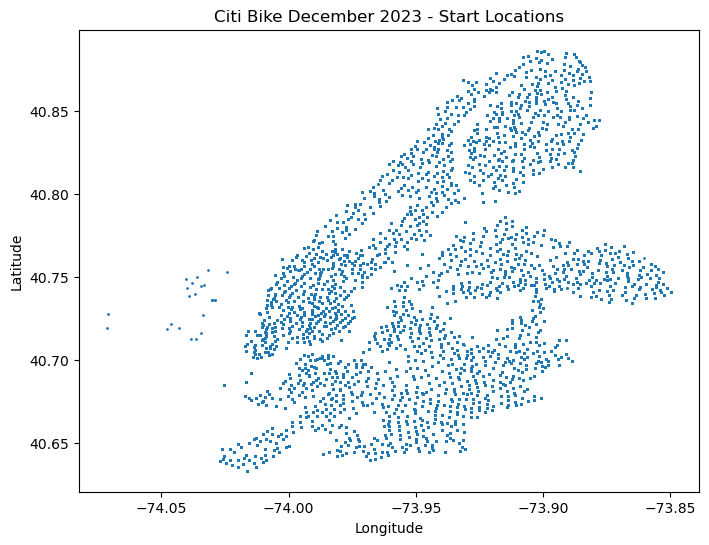

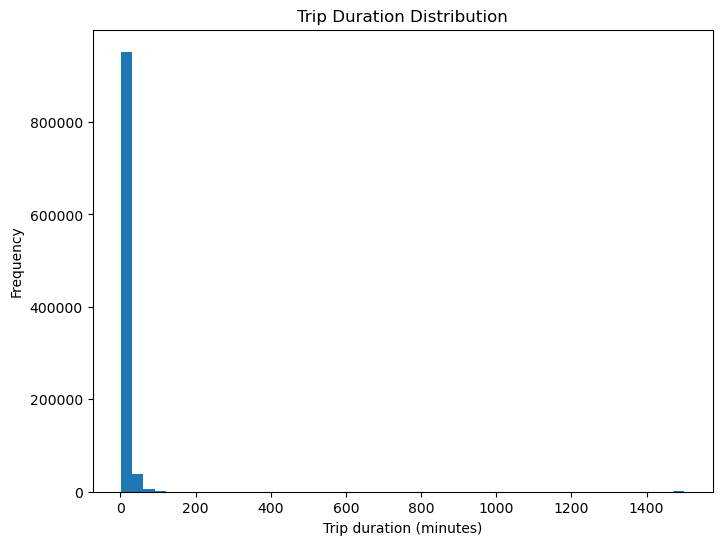

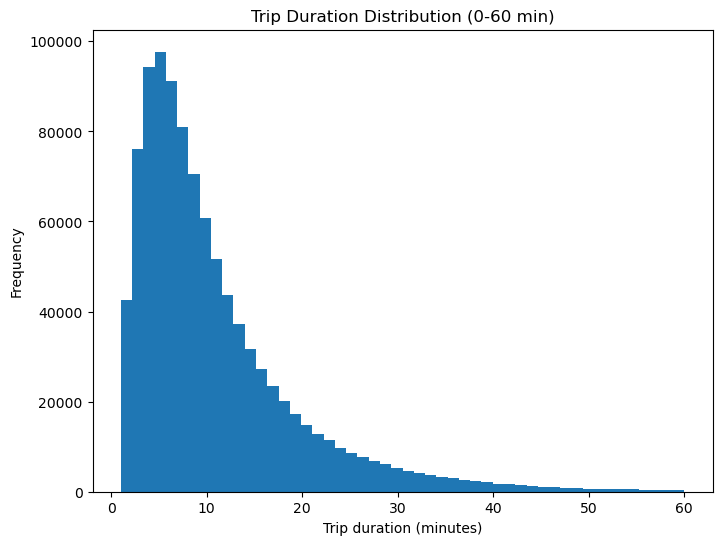

In [3]:
# ============================================
# Sanity checks + quick visualization
# ============================================

import matplotlib.pyplot as plt

print("----- SANITY CHECKS -----")

# 1. Basic shape
print(f"Number of rows: {len(clean_df)}")
print()

# 2. Missing values
print("Missing values per column:")
print(clean_df.isna().sum())
print()

# 3. Duplicate ids
print("Duplicate id count:", clean_df["id"].duplicated().sum())
print()

# 4. Duration checks
print("Trip duration summary (minutes):")
print(clean_df["trip_duration_minutes"].describe())
print()

print("Trips with non-positive duration:",
      (clean_df["trip_duration_minutes"] <= 0).sum())
print()

# 5. Coordinate range checks
print("Longitude summary:")
print(clean_df["longitude"].describe())
print()

print("Latitude summary:")
print(clean_df["latitude"].describe())
print()

# Rough NYC bounding box sanity check
invalid_geo = clean_df[
    (clean_df["longitude"] < -74.3) | (clean_df["longitude"] > -73.6) |
    (clean_df["latitude"]  < 40.4)  | (clean_df["latitude"]  > 41.0)
]

print("Rows outside rough NYC bounding box:", len(invalid_geo))
print()

# 6. Show suspiciously long trips
very_long = clean_df[clean_df["trip_duration_minutes"] > 180]
print("Trips longer than 180 minutes:", len(very_long))
print()

if len(very_long) > 0:
    print("Sample long trips:")
    display(very_long.head())

# ============================================
# Visualization
# ============================================

# Scatter plot of trip start points
plt.figure(figsize=(8, 6))
plt.scatter(clean_df["longitude"], clean_df["latitude"], s=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Citi Bike December 2023 - Start Locations")
plt.show()

# Histogram of trip duration
plt.figure(figsize=(8, 6))
plt.hist(clean_df["trip_duration_minutes"], bins=50)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Frequency")
plt.title("Trip Duration Distribution")
plt.show()

# Optional: zoomed histogram for more readable durations
plt.figure(figsize=(8, 6))
plt.hist(clean_df.loc[clean_df["trip_duration_minutes"] <= 60, "trip_duration_minutes"], bins=50)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Frequency")
plt.title("Trip Duration Distribution (0-60 min)")
plt.show()